# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import warnings
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [12]:
corpus = """
Artificial intelligence is transforming our world rapidly. At its core, AI refers to computer systems designed to perform tasks that typically require human intelligence. These tasks include visual perception, speech recognition, decision-making, and natural language translation. Modern machine learning algorithms analyze vast datasets to identify intricate patterns and make predictions. Consequently, global businesses leverage this technology to automate routine operations, optimize complex supply chains, and enhance customer experiences through personalized recommendations.

In healthcare, intelligent AI models assist doctors by analyzing medical images to detect diseases early, potentially saving thousands of lives. Meanwhile, autonomous vehicles navigate busy city streets using real-time sensor data, completely redefining the future of transportation. However, this rapid technological advancement raises critical ethical questions regarding data privacy, algorithmic bias, and workforce displacement. As automation replaces traditional jobs, society must adapt by upskilling workers for the digital economy.

Ultimately, the future of AI depends on responsible development and robust regulatory frameworks. Ensuring transparency, accountability, and fairness in algorithmic decision-making is essential to mitigate systemic risks. By balancing technological innovation with ethical considerations, humanity can successfully harness the full potential of artificial intelligence to build a much safer, more efficient, and truly equitable global society today for everyone everywhere.
"""

print(corpus)


Artificial intelligence is transforming our world rapidly. At its core, AI refers to computer systems designed to perform tasks that typically require human intelligence. These tasks include visual perception, speech recognition, decision-making, and natural language translation. Modern machine learning algorithms analyze vast datasets to identify intricate patterns and make predictions. Consequently, global businesses leverage this technology to automate routine operations, optimize complex supply chains, and enhance customer experiences through personalized recommendations.

In healthcare, intelligent AI models assist doctors by analyzing medical images to detect diseases early, potentially saving thousands of lives. Meanwhile, autonomous vehicles navigate busy city streets using real-time sensor data, completely redefining the future of transportation. However, this rapid technological advancement raises critical ethical questions regarding data privacy, algorithmic bias, and workf

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [14]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 165
X shape: (200, 71)
y shape: (200,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [16]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [17]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [18]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

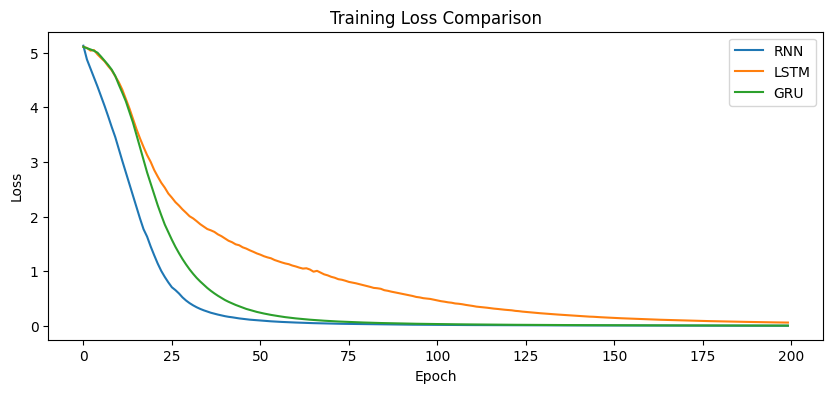

In [19]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [20]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [21]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning the future of ai depends on responsible development and robust
LSTM: deep learning intelligence is transforming our world rapidly at its core ai
GRU : deep learning healthcare intelligent ai models assist doctors by analyzing medical images


In [22]:
print("RNN :", generate_text(rnn_model, "deep learning", 30))
print("LSTM:", generate_text(lstm_model, "deep learning", 30))
print("GRU :", generate_text(gru_model, "deep learning", 30))

RNN : deep learning the future of ai depends on responsible development and robust regulatory frameworks ensuring transparency accountability and fairness in algorithmic decision making is essential to mitigate systemic risks by balancing technological
LSTM: deep learning intelligence is transforming our world rapidly at its core ai refers to computer systems designed to perform tasks that typically require human intelligence these tasks include visual perception speech recognition
GRU : deep learning healthcare intelligent ai models assist doctors by analyzing medical images to detect diseases early potentially saving thousands of lives meanwhile autonomous vehicles navigate busy city streets using real time sensor


# 📚 Student Learning Tasks (Completed)

✅ Custom paragraph corpus added

✅ Embedding dimension increased from 32 → 128

✅ Training epochs increased from 100 → 200

✅ Hidden units increased from 64 → 128

✅ Text generation output increased from 5 → 10 words

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**